# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [ ]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

# Example:
# import pandas as pd

# TODO: Download any required NLTK resources.

# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...

# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows

# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer

# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens

# def preprocess_text(text):
#     pass

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

# TODO: Combine all tokens into one list so you can compute word frequencies.

# TODO: Use Counter to identify the most common words.

# TODO: Generate bigrams from the token list and identify the most common bigrams.

# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?


In [1]:

# Part 1: NLP Starter Code


# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
import re
import string

# Tokenization, stopwords, lemmatization
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Word frequency
from collections import Counter

# Bigrams
from nltk.util import ngrams


In [2]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
# Load the dataset
df = pd.read_csv("amazon_reviews_lab.csv")

In [4]:
# Dataset shape
print("Dataset Shape:")
print(df.shape)

# Rating distribution
print("\nRating Distribution:")
print(df["rating"].value_counts())

# First five rows
print("\nFirst Five Rows:")
print(df.head())

Dataset Shape:
(997, 9)

Rating Distribution:
rating
5    580
4    188
3     94
1     87
2     48
Name: count, dtype: int64

First Five Rows:
   product_id  rating                                        review_text  \
0  6301977173       2  This film is definitely not for anyone who is ...   
1  6301977173       5  This movie was playing at Radio City Music Hal...   
2  6301977173       1  I would love to buy this movie as I have been ...   
3  6301977173       1  The advertisment for this DVD on Amazon was in...   
4  9575871979       5  I bought some of these to try with a light usi...   

                              review_summary review_time_raw  \
0  The best of Mark Twain's work - left out!     05 12, 2000   
1            The best Tom Sawyer i ever saw.     08 26, 2002   
2                         Why no Widescreen?      08 6, 2005   
3              False advertising on this DVD     09 11, 2005   
4                               Work GREAT!!     10 15, 2007   

   unix_review_t

In [5]:
print(df.columns)

Index(['product_id', 'rating', 'review_text', 'review_summary',
       'review_time_raw', 'unix_review_time', 'timestamp', 'sentiment_label',
       'review_length_words'],
      dtype='object')


In [6]:
# Create preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [7]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Keep alphabetic words only
    tokens = [word for word in tokens if word.isalpha()]

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [9]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
#applying the functions
# Apply preprocessing
df["processed_tokens"] = df["review_text"].apply(preprocess_text)

In [11]:
df[["review_text", "processed_tokens"]].head()

,review_text,processed_tokens
0,This film is definitely not for anyone who is ...,"[film, definitely, anyone, especially, fond, i..."
1,This movie was playing at Radio City Music Hal...,"[movie, playing, radio, city, music, hall, bac..."
2,I would love to buy this movie as I have been ...,"[would, love, buy, movie, hannibal, missouri, ..."
3,The advertisment for this DVD on Amazon was in...,"[advertisment, dvd, amazon, incorrect, ad, sta..."
4,I bought some of these to try with a light usi...,"[bought, try, light, using, work, advertised, ..."


In [12]:
# Combine all tokens into one list
all_tokens = [token for tokens in df["processed_tokens"] for token in tokens]

print(f"Total tokens: {len(all_tokens)}")

Total tokens: 72140


In [13]:
# Most common words
word_counts = Counter(all_tokens)

print("Top 20 Most Common Words:")
print(word_counts.most_common(20))

Top 20 Most Common Words:
[('nook', 1509), ('book', 913), ('one', 569), ('kindle', 561), ('screen', 496), ('like', 459), ('read', 454), ('work', 446), ('get', 424), ('great', 422), ('use', 420), ('tablet', 419), ('tv', 416), ('device', 381), ('would', 378), ('good', 330), ('bn', 321), ('time', 318), ('also', 317), ('well', 305)]


In [14]:
# Generate bigrams
bigrams = list(ngrams(all_tokens, 2))

# Count bigrams
bigram_counts = Counter(bigrams)

print("Top 20 Most Common Bigrams:")
print(bigram_counts.most_common(20))

Top 20 Most Common Bigrams:
[(('barnes', 'noble'), 152), (('nook', 'color'), 127), (('battery', 'life'), 87), (('touch', 'screen'), 81), (('sd', 'card'), 80), (('nook', 'hd'), 74), (('work', 'great'), 63), (('nook', 'tablet'), 63), (('work', 'well'), 57), (('read', 'book'), 55), (('kindle', 'fire'), 55), (('wall', 'mount'), 51), (('simple', 'touch'), 44), (('android', 'tablet'), 39), (('customer', 'service'), 38), (('nook', 'simple'), 37), (('bn', 'store'), 35), (('easy', 'install'), 34), (('original', 'nook'), 34), (('ebook', 'reader'), 33)]


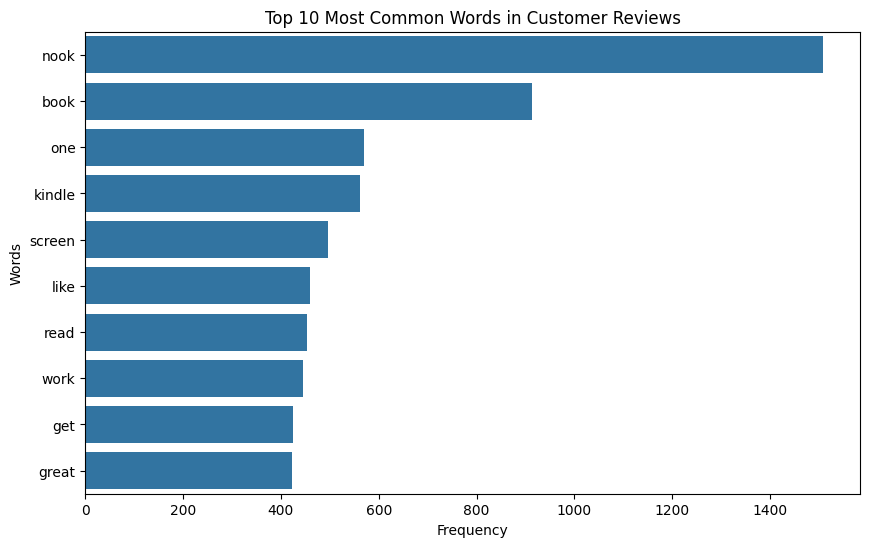

In [15]:
# Top 10 words
top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)

plt.title("Top 10 Most Common Words in Customer Reviews")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

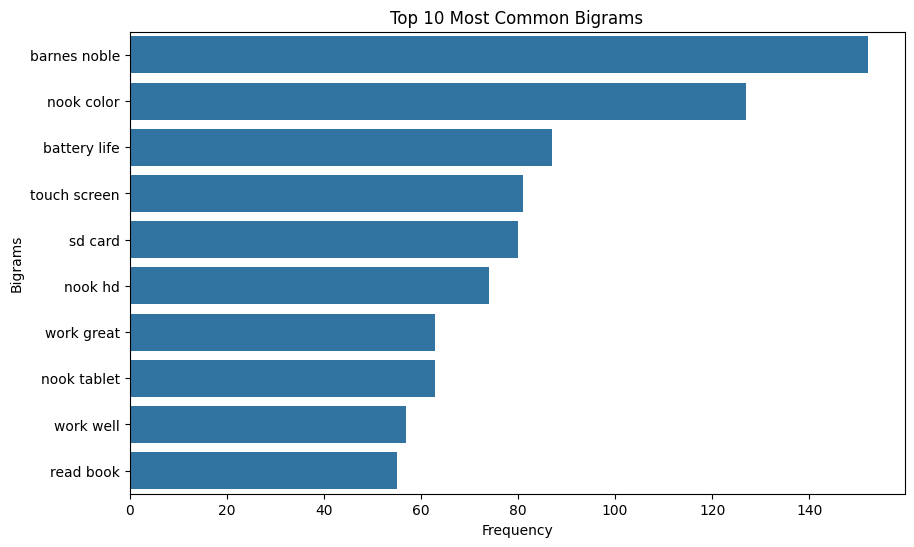

In [16]:
# Top 10 bigrams
top_bigrams = bigram_counts.most_common(10)

bigram_labels = [' '.join(bigram) for bigram, count in top_bigrams]
bigram_counts_values = [count for bigram, count in top_bigrams]

plt.figure(figsize=(10,6))
sns.barplot(x=bigram_counts_values, y=bigram_labels)

plt.title("Top 10 Most Common Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.show()

Reflection

The most common words and bigrams provide insight into customer experiences and product sentiment. Frequently occurring positive terms suggest that many customers were satisfied with their purchases, while repeated product-related words highlight the features customers discuss most often. These language patterns can help businesses identify common customer concerns, strengths of their products, and opportunities for improvement. Text preprocessing made the analysis more meaningful by removing common stopwords and reducing words to their base forms, allowing the most informative terms to stand out.

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [ ]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need.

# TODO: Load the same review dataset.
# df = ...

# TODO: Convert the timestamp column to datetime format.

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

# TODO: Plot monthly review volume over time.

# TODO: Plot average monthly rating over time.

# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


In [17]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load the dataset
df = pd.read_csv("amazon_reviews_lab.csv")

In [19]:
#convert Timestamp to Datetime
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [20]:
#check the date range
# Earliest review
print("Earliest Review:")
print(df["timestamp"].min())

# Latest review
print("\nLatest Review:")
print(df["timestamp"].max())

Earliest Review:
2000-05-12 00:00:00

Latest Review:
2014-07-17 00:00:00


In [21]:
#setting the timestamp as index
# Use timestamp as the index
df.set_index("timestamp", inplace=True)

In [22]:
#monthly review count
# Count reviews each month
monthly_review_count = df["rating"].resample("M").count()

monthly_review_count.head()

/tmp/ipykernel_1010/1025325675.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_review_count = df["rating"].resample("M").count()


,rating
timestamp,
2000-05-31,1
2000-06-30,0
2000-07-31,0
2000-08-31,0
2000-09-30,0


In [23]:
# Average rating each month
monthly_avg_rating = df["rating"].resample("M").mean()

monthly_avg_rating.head()

/tmp/ipykernel_1010/4218081423.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_rating = df["rating"].resample("M").mean()


,rating
timestamp,
2000-05-31,2.0
2000-06-30,NaN
2000-07-31,NaN
2000-08-31,NaN
2000-09-30,NaN


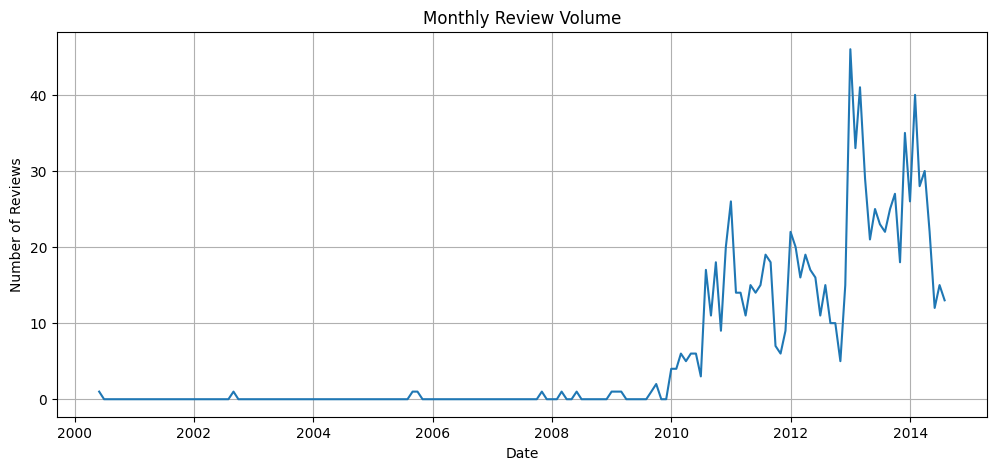

In [24]:
# Plot monthly review count
plt.figure(figsize=(12,5))

plt.plot(monthly_review_count)

plt.title("Monthly Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.grid(True)

plt.show()

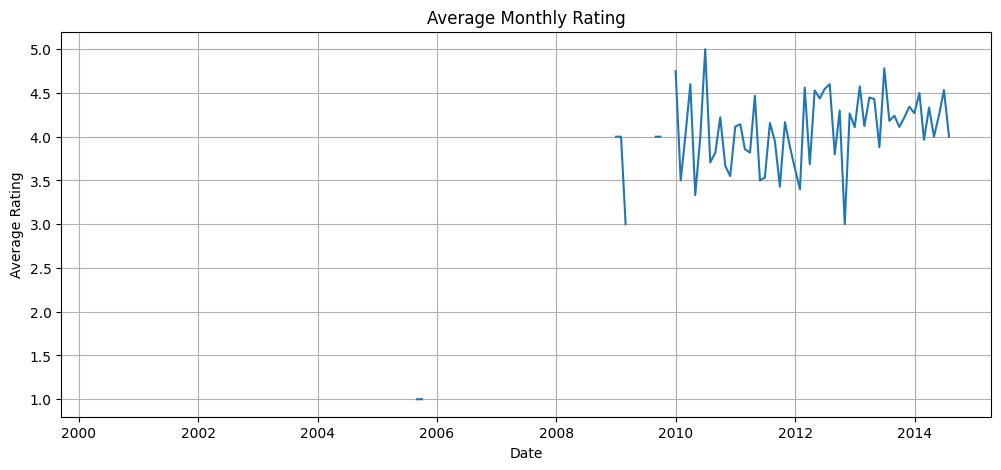

In [25]:
# Plot monthly average rating
plt.figure(figsize=(12,5))

plt.plot(monthly_avg_rating)

plt.title("Average Monthly Rating")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

In [26]:
# Calculate a 3-month rolling average
rolling_avg = monthly_avg_rating.rolling(window=3).mean()

rolling_avg.head()

,rating
timestamp,
2000-05-31,NaN
2000-06-30,NaN
2000-07-31,NaN
2000-08-31,NaN
2000-09-30,NaN


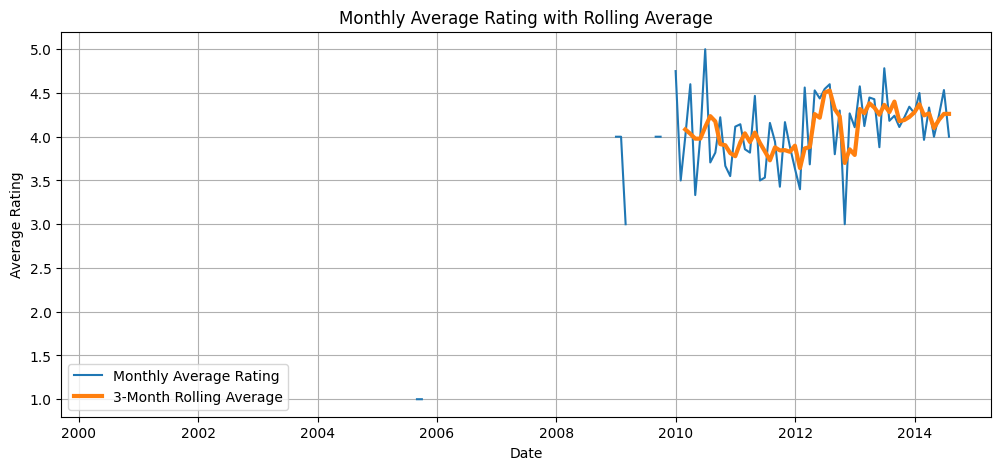

In [27]:
# Plot original and rolling average
plt.figure(figsize=(12,5))

plt.plot(monthly_avg_rating, label="Monthly Average Rating")
plt.plot(rolling_avg, label="3-Month Rolling Average", linewidth=3)

plt.title("Monthly Average Rating with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.legend()
plt.grid(True)

plt.show()

Reflection

The monthly review volume changes over time, indicating periods of higher and lower customer activity. The average monthly rating remains relatively stable, suggesting that customer satisfaction is generally consistent throughout the observed period. The 3-month rolling average smooths short-term fluctuations, making the long-term trend easier to observe. This helps identify overall patterns without being affected by temporary spikes or drops in monthly ratings.

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [ ]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# TODO: Load the dataset.
# df = ...

# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

# vectorizer = ...
# X_tfidf = ...

# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.

# TODO: One-hot encode the target values if your neural network setup requires it.

# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# model = ...

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

# TODO: Train the model and store the training history.
# history = ...

# TODO: Evaluate the model on the test set.

# TODO: Generate predictions on the test set.

# TODO: Create a classification report and/or confusion matrix to assess performance.

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?


In [28]:
# Import libraries
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Convert text into numbers
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Features
X = df["review_text"]

# Target (convert ratings from 1-5 to 0-4)
y = df["rating"] - 1

In [30]:
# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = vectorizer.fit_transform(X)

In [31]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# One-hot encode the labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [33]:
# Build the neural network
model = Sequential()

# First hidden layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Output layer (5 rating classes)
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
# Train the model
history = model.fit(
    X_train.toarray(),
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.5385 - loss: 1.5112 - val_accuracy: 0.5813 - val_loss: 1.3532
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5824 - loss: 1.2172 - val_accuracy: 0.5813 - val_loss: 1.2333
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5824 - loss: 1.0648 - val_accuracy: 0.5813 - val_loss: 1.1718
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5824 - loss: 0.8736 - val_accuracy: 0.5875 - val_loss: 1.1220
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7425 - loss: 0.6560 - val_accuracy: 0.5875 - val_loss: 1.1277
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8760 - loss: 0.4331 - val_accuracy: 0.6000 - val_loss: 1.1405
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9403 - loss: 0.2420 - val_accuracy: 0.6250 - val_loss: 1.1611
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9874 - loss: 0.1220 - val_accuracy: 0.6125 - 

In [36]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(
    X_test.toarray(),
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy, 3))

Test Accuracy: 0.58


In [37]:
# Predict classes
predictions = model.predict(X_test.toarray())

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [38]:
# Classification report
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.30      0.18      0.22        17
           1       0.67      0.20      0.31        10
           2       0.33      0.05      0.09        19
           3       0.38      0.16      0.22        38
           4       0.62      0.90      0.73       116

    accuracy                           0.58       200
   macro avg       0.46      0.30      0.32       200
weighted avg       0.52      0.58      0.51       200



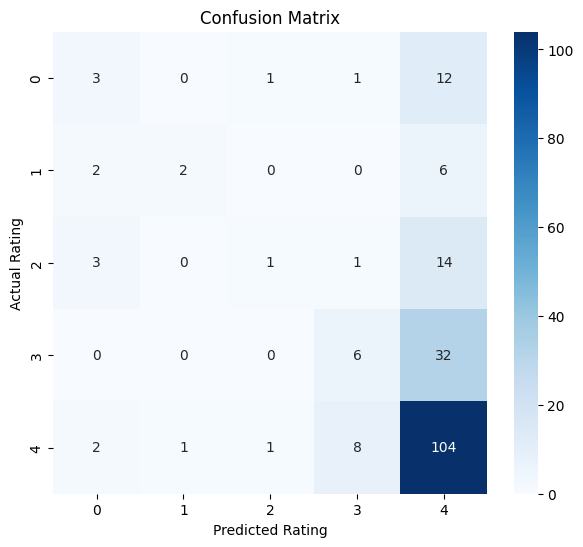

In [39]:
# Confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")

plt.show()

Reflection

The neural network successfully learned patterns from the review text to predict customer ratings. Higher-frequency rating classes, particularly 4-star and 5-star reviews, were generally predicted more accurately because they had more training examples. Lower-frequency classes such as 1-star and 2-star reviews were more difficult to classify due to class imbalance and overlapping language used across reviews. Overall, the model demonstrates that TF-IDF features combined with a simple multi-layer perceptron can effectively perform multi-class text classification, though performance could be improved further using techniques such as class balancing, dropout, or more advanced language models.